# CA1: Dataframe Manipulation with Spotify Data

## Introduction
Pandas is an extremely powerful tool to handle large amounts of tabular data. In this compulsory assignment, you will use Pandas to explore one of the TA's personal spotify data in depth. \
\
Additional information:
- Feel free to create additional code cells if you feel that one cell per subtask is not sufficient.
- Remember, Pandas uses very efficient code to handle large amounts of data. For-loops are not efficient. If you ever have to use a for-loop to loop over the rows in the DataFrame, you have *probably* done something wrong.
- Label all graphs and charts if applicable.

## Task
I typically enjoy indie and rock music. I am a big fan of everything from old-fashioned rock and roll like Led Zeppelin and Jimi Hendrix, to newer indie artists like Joji and Lana Del Rey. This is why my spotify wrapped for 2023 came as quite a surprise:

<img src="spotifywrapped.PNG" alt="Image Description" width="20%">


Now, I'm no hater of pop music, but this was unexpected. 
For this assignment, you will investigate my listening habits, including a deep dive into my Ariana Grande listening habits, and try to find an answer to why she was my top artist; was there a fault in the spotify algorithm? Am I actually secretly an *Arianator*? (yes, I did have to look that up). Or am I just lying to myself about how often I listen to guilty pleasure music?

## Part 1: Initial loading and exploration

#### 1.0 Import necessary libraries: 
pandas, numpy, matplotlib.pyplot (other libraries such as seaborn or plotly are also allowed if you want prettier plots). It might also be a good idea to use **os** for task 2.0

In [342]:
import matplotlib.pyplot as plt
# ---- Insert other imports ----
import pandas as pd
import pathlib as pl
from datetime import datetime
import matplotlib.pyplot as plt

#### 1.1 Loading the data
Load the dataset in the file `streaming_history_0.csv` into a Pandas DataFrame called `df_spotify_0`.

In [343]:
df_spotify_0 = pd.read_csv(r"spotify_data\streaminghistory0.csv")

#### 1.2 Help function
Use the Python command `help` to help you understand how to use the `pd.DataFrame.head` and `pd.DataFrame.tail` methods.

In [344]:
help(pd.DataFrame.head)
help(pd.DataFrame.tail)

Help on function head in module pandas.core.generic:

head(self, n: int = 5) -> Self
    Return the first `n` rows.

    This function exhibits the same behavior as ``df[:n]``, returning the
    first ``n`` rows based on position. It is useful for quickly checking
    if your object has the right type of data in it.

    When ``n`` is positive, it returns the first ``n`` rows. For ``n`` equal to 0,
    it returns an empty object. When ``n`` is negative, it returns
    all rows except the last ``|n|`` rows, mirroring the behavior of ``df[:n]``.

    If ``n`` is larger than the number of rows, this function returns all rows.

    Parameters
    ----------
    n : int, default 5
        Number of rows to select.

    Returns
    -------
    same type as caller
        The first `n` rows of the caller object.

    See Also
    --------
    DataFrame.tail: Returns the last `n` rows.

    Examples
    --------
    >>> df = pd.DataFrame(
    ...     {
    ...         "animal": [
    ...      

#### 1.3 Getting an overview
Print the first `five` and last `ten` rows of the dataframe. Have a quick look at which columns are in the dataset. 

In [345]:
print(df_spotify_0.head(5))
print(df_spotify_0.tail(10))

            endTime            artistName                        trackName  \
0  2022-12-03 02:02  Cigarettes After Sex                            Truly   
1  2022-12-03 02:02         Leonard Cohen  Take This Waltz - Paris Version   
2  2022-12-06 21:05          Vlad Holiday                 So Damn Into You   
3  2022-12-06 21:05                 Lorde                             Team   
4  2022-12-06 21:05         Ariana Grande                         Into You   

   msPlayed  
0   30000.0  
1    8210.0  
2   37895.0  
3    8984.0  
4    1221.0  
                endTime         artistName                     trackName  \
11949  2023-01-02 20:58      Ariana Grande                    six thirty   
11950  2023-01-02 20:58      Leonard Cohen          Thanks for the Dance   
11951  2023-01-02 20:59           Des Rocs          Used to the Darkness   
11952  2023-01-02 20:59  Caroline Polachek         Hit Me Where It Hurts   
11953  2023-01-02 20:59  Caroline Polachek         Hit Me Where It 

#### 1.4 Formatting correctly
When working with Pandas, it's very useful to have columns which contains dates in a specific format called *datetime*. This allows for efficient manipulation and analysis of time-series data, such as sorting, filtering by date or time, and resampling for different time periods. Figure out which column(s) would be appropriate to convert to datetime, if any, and if so, perform the conversion to the correct format.

In [346]:
# The endTime colum seems most appropriate to convert to datetime

df_spotify_0["endTime"] = pd.to_datetime(df_spotify_0["endTime"])
df_spotify_0.head(5)



,endTime,artistName,trackName,msPlayed
0,2022-12-03 02:02:00,Cigarettes After Sex,Truly,30000.0
1,2022-12-03 02:02:00,Leonard Cohen,Take This Waltz - Paris Version,8210.0
2,2022-12-06 21:05:00,Vlad Holiday,So Damn Into You,37895.0
3,2022-12-06 21:05:00,Lorde,Team,8984.0
4,2022-12-06 21:05:00,Ariana Grande,Into You,1221.0


#### 1.5 Unique artists
Find how many unique artists are in the dataset.


In [347]:
print(f"The dataset contains {len(pd.unique(df_spotify_0["artistName"]))} unique artists")

The dataset contains 495 unique artists


#### 1.6 Unique songs
Find how many unique songs are in the dataset.

In [348]:
print(f"The dataset contains {len(pd.unique(df_spotify_0["trackName"]))} unique songs")


The dataset contains 1308 unique songs


### Part 1: Questions
Q1: Which columns are in the dataset?

The dataset contains the columns endTime, artistName, trackName and msPlayed

Q2: What timeframe does the dataset span?

The dataset spans from 2022-12-03 to 2023-01-02

Q3: How many unique artists are in the dataset?

The dataset contains 495 unique artists

Q4: How many unique songs are in the dataset?

The dataset contains 1308 unique songs

In [349]:
# Q2
print(f"Q2: The dataset spans from {min(df_spotify_0["endTime"]).date()} to {max(df_spotify_0["endTime"]).date()}")

Q2: The dataset spans from 2022-12-03 to 2023-01-02


## Part 2: Working with all the data

#### 2.0 Importing all the dataframes
In Task 1, you only worked with about a month worth of data. Now, you will work with over a year worth. 

In the *spotify_data* folder, there is more than just one listening record. Load each of the 14 listening records into a dataframe (1 dataframe per listening record), and concatenate them together into one large dataframe named `df`.

In [350]:
data = pl.Path(r"spotify_data")

df_spotify_0
for idx, dataset in enumerate(list(data.glob("*.csv"))[1:]):
    if idx == 0:
        df = pd.concat([df_spotify_0, pd.read_csv(dataset)])
    else:
        df = pd.concat([df, pd.read_csv(dataset)])
        
df["endTime"] = pd.to_datetime(df["endTime"])
df
    

,endTime,artistName,trackName,msPlayed
0,2022-12-03 02:02:00,Cigarettes After Sex,Truly,30000.0
1,2022-12-03 02:02:00,Leonard Cohen,Take This Waltz - Paris Version,8210.0
2,2022-12-06 21:05:00,Vlad Holiday,So Damn Into You,37895.0
3,2022-12-06 21:05:00,Lorde,Team,8984.0
4,2022-12-06 21:05:00,Ariana Grande,Into You,1221.0
...,...,...,...,...
11954,2023-08-11 08:46:00,Tears For Fears,Head Over Heels,26426.0
11955,2023-08-11 08:47:00,TV Girl,Not Allowed,24712.0
11956,2023-08-11 08:47:00,Ariana Grande,My Everything,8261.0
11957,2023-08-11 09:11:00,Ariana Grande,Break Free,16787.0


#### 2.1 Sorting by time
Datasets often aren't perfect. One example of an issue that could occur is that the time-based data might not be in chronological order. If this were to happen, the rows in your dataframe could be in the wrong order. To ensure this isn't an issue in your dataframe, you should sort the dataframe in chronological order, from oldest to newest.

In [351]:
df = df.sort_values(by="endTime")
df

,endTime,artistName,trackName,msPlayed
0,2022-12-03 02:02:00,Cigarettes After Sex,Truly,30000.0
1,2022-12-03 02:02:00,Leonard Cohen,Take This Waltz - Paris Version,8210.0
2,2022-12-06 21:05:00,Vlad Holiday,So Damn Into You,37895.0
3,2022-12-06 21:05:00,Lorde,Team,8984.0
4,2022-12-06 21:05:00,Ariana Grande,Into You,1221.0
...,...,...,...,...
11964,2023-12-07 21:13:00,Lana Del Rey,Ride,1126.0
11969,2023-12-07 21:14:00,Ariana Grande,my hair,23757.0
11970,2023-12-07 21:14:00,Leonard Cohen,Thanks for the Dance,9317.0
11971,2023-12-07 21:17:00,The Vaccines,Your Love Is My Favourite Band,14661.0


#### 2.2 Setting a timeframe
For this investigation, we are only interested in investigating listening patterns from **2023**. Remove any data not from **2023** from the DataFrame.

In [352]:
df = df.loc[df["endTime"] > datetime(2023, 1, 1)]
df

,endTime,artistName,trackName,msPlayed
10881,2023-01-01 01:17:00,Ariana Grande,7 rings,139.0
10882,2023-01-01 01:17:00,Ariana Grande,7 rings,487.0
10883,2023-01-01 01:17:00,Ariana Grande,positions,417.0
10884,2023-01-01 01:17:00,Peach Pit,Being so Normal,2205.0
10885,2023-01-01 01:17:00,Kelly Clarkson,"Santa, Can’t You Hear Me",278.0
...,...,...,...,...
11959,2023-12-07 21:13:00,Lana Del Rey,Young And Beautiful,3146.0
11964,2023-12-07 21:13:00,Lana Del Rey,Ride,1126.0
11969,2023-12-07 21:14:00,Ariana Grande,my hair,23757.0
11970,2023-12-07 21:14:00,Leonard Cohen,Thanks for the Dance,9317.0


#### 2.3 Deleting rows
Often in Data Science, you will encounter when a row entry has the value *NaN*, indicating missing data. These entries can skew your analysis, leading to inaccurate conclusions. For this task, identify and remove any rows in your DataFrame that contain NaN values. \
Later in the course, you might encounter other techniques of dealing with missing data, typically reffered to as *data imputation*. Here, though, you are just supposed to delete the entire rows with missing data.

In [353]:
df_NaN = pd.isna(df)

for column_name in df.columns:
    found_NaN = df_NaN.loc[df_NaN[column_name] == 1]
    
    for idx in found_NaN.index:
        df = df.drop(index=idx)
df

,endTime,artistName,trackName,msPlayed
10881,2023-01-01 01:17:00,Ariana Grande,7 rings,139.0
10882,2023-01-01 01:17:00,Ariana Grande,7 rings,487.0
10883,2023-01-01 01:17:00,Ariana Grande,positions,417.0
10884,2023-01-01 01:17:00,Peach Pit,Being so Normal,2205.0
10885,2023-01-01 01:17:00,Kelly Clarkson,"Santa, Can’t You Hear Me",278.0
...,...,...,...,...
11959,2023-12-07 21:13:00,Lana Del Rey,Young And Beautiful,3146.0
11964,2023-12-07 21:13:00,Lana Del Rey,Ride,1126.0
11969,2023-12-07 21:14:00,Ariana Grande,my hair,23757.0
11970,2023-12-07 21:14:00,Leonard Cohen,Thanks for the Dance,9317.0


#### 2.4 Convert from milliseconds to seconds
From `msPlayed`, create a new column `secPlayed` with the data converted from milliseconds to seconds. Then delete the column `msPlayed`.

In [354]:
df["secPlayed"] = df["msPlayed"] / 1000
df = df.drop(columns="msPlayed")
df

,endTime,artistName,trackName,secPlayed
10881,2023-01-01 01:17:00,Ariana Grande,7 rings,0.139
10882,2023-01-01 01:17:00,Ariana Grande,7 rings,0.487
10883,2023-01-01 01:17:00,Ariana Grande,positions,0.417
10884,2023-01-01 01:17:00,Peach Pit,Being so Normal,2.205
10885,2023-01-01 01:17:00,Kelly Clarkson,"Santa, Can’t You Hear Me",0.278
...,...,...,...,...
11959,2023-12-07 21:13:00,Lana Del Rey,Young And Beautiful,3.146
11964,2023-12-07 21:13:00,Lana Del Rey,Ride,1.126
11969,2023-12-07 21:14:00,Ariana Grande,my hair,23.757
11970,2023-12-07 21:14:00,Leonard Cohen,Thanks for the Dance,9.317


#### 2.5 Finding top 10 favorite artists
Find the top `ten` artists with the highest total play time (in seconds). Plot your findings in a bar graph. \
(hint: start by creating a new DataFrame with only `artistName` and your time column. To proceed, you will also likely need the `groupby` command from Pandas.)

<Axes: xlabel='artistName'>

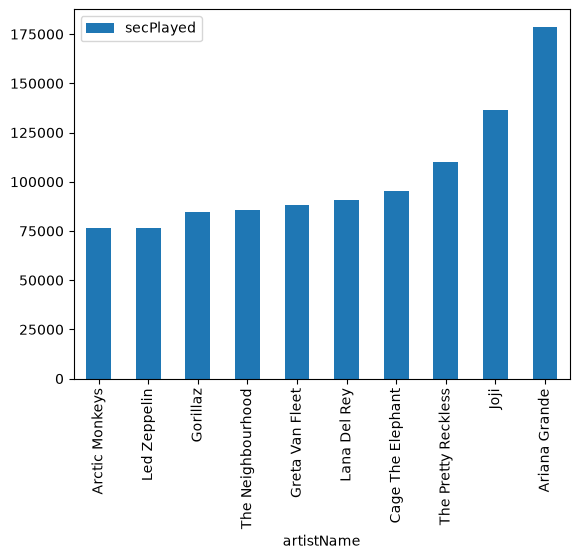

In [355]:
df_fav = df.drop(columns=["endTime", "trackName"])
df_fav = df_fav.groupby("artistName").sum()
df_fav = df_fav.sort_values(by="secPlayed")
df_fav = df_fav.tail(10)
df_fav.plot.bar()

#### 2.6 Finding top 10 favorite songs
Find the top `ten` songs with the highest play time. Create a graph visualizing the results.

<Axes: xlabel='trackName'>

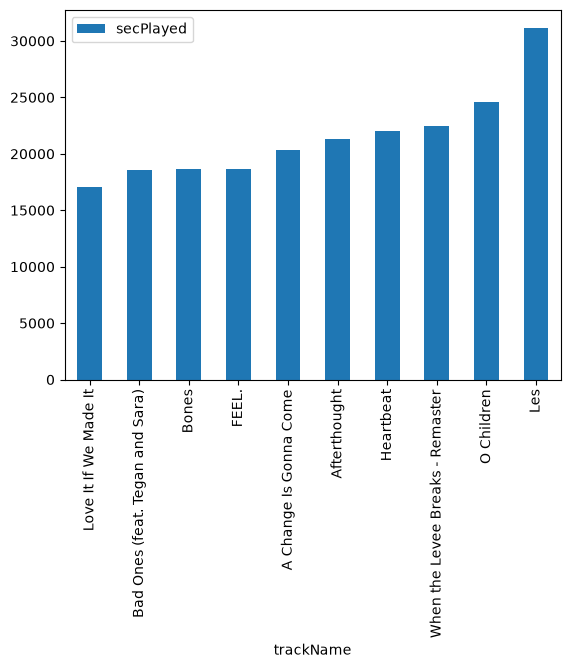

In [356]:
df_fav_song = df.drop(columns=["endTime", "artistName"])
df_fav_song = df_fav_song.groupby("trackName").sum()
df_fav_song = df_fav_song.sort_values(by="secPlayed")
df_fav_song = df_fav_song.tail(10)
df_fav_song.plot.bar()

## Part 3: Further analysis

#### 3.0 Average listening time by hour
Generate a plot that displays the average amount of time that music is played for each hour of the day.

<Axes: title={'center': 'Average listening time by hour'}, xlabel='endTime'>

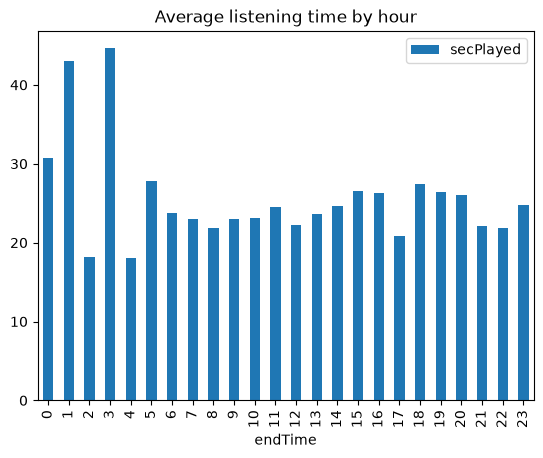

In [357]:
df_hour = df.copy()
df_hour["endTime"] = df_hour["endTime"].dt.hour
df_hour = df_hour.drop(columns=["trackName", "artistName"])
df_hour = df_hour.groupby("endTime").mean()
df_hour.plot.bar(title="Average listening time by hour")

#### 3.1 Morning music and evening music
I think many people find that some types of music are more suitable for morning listening and some music is more suitable for evening listening. Create a plot that compares the play time of the artists *Leonard Cohen* and *Rage Against the Machine* on an hour-by-hour basis. See if there are any differences.

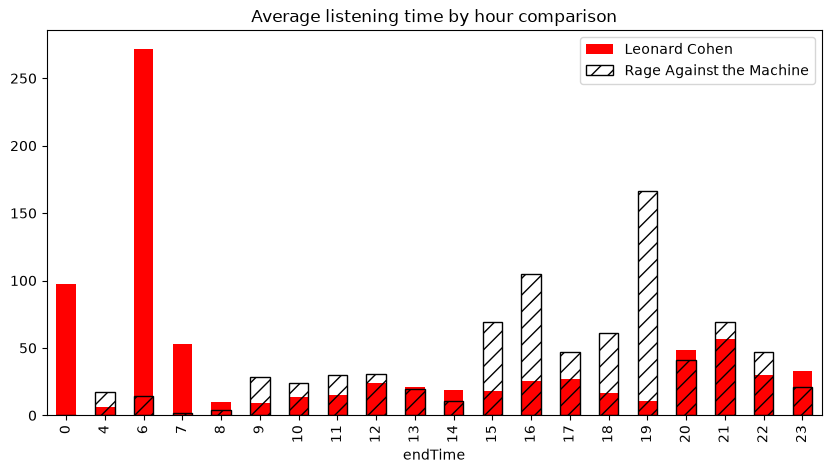

In [358]:
df_time_day = df.copy()
df_time_day["endTime"] = df_time_day["endTime"].dt.hour

fig, ax = plt.subplots(figsize=(10, 5))

df_time_day_Leo = df_time_day.loc[df_time_day["artistName"] == "Leonard Cohen"]
df_time_day_Leo = df_time_day_Leo.drop(columns=["trackName", "artistName"])
df_time_day_Leo = df_time_day_Leo.groupby("endTime").mean()
df_time_day_Leo.plot.bar(ax=ax, color="red")

df_time_day_machine= df_time_day.loc[df_time_day["artistName"] == "Rage Against The Machine"]
df_time_day_machine = df_time_day_machine.drop(columns=["trackName", "artistName"])
df_time_day_machine = df_time_day_machine.groupby("endTime").mean()
df_time_day_machine.plot.bar(ax=ax,
                            title="Average listening time by hour comparison",
                            facecolor="none",
                            hatch="//",
                            edgecolor="black",
                            label="Rage Against The Machine")

ax.legend(["Leonard Cohen", "Rage Against the Machine"])

#### 3.2 Analysing skipped songs
Determining whether a song was skipped or listened to can be challenging. For this analysis, we'll simplify by defining a skipped song as any track played for less than 30 seconds. Conversely, a song played for 30 seconds or more is considered listened to. \
 Add a column to your DataFrame to reflect this criteria: set the value to 1 if the song was played for less than 30 seconds (indicating a skipped song), and 0 if it was played for 30 seconds or longer.

In [359]:
df["skippedSong"] = df["secPlayed"] < 30
df

,endTime,artistName,trackName,secPlayed,skippedSong
10881,2023-01-01 01:17:00,Ariana Grande,7 rings,0.139,True
10882,2023-01-01 01:17:00,Ariana Grande,7 rings,0.487,True
10883,2023-01-01 01:17:00,Ariana Grande,positions,0.417,True
10884,2023-01-01 01:17:00,Peach Pit,Being so Normal,2.205,True
10885,2023-01-01 01:17:00,Kelly Clarkson,"Santa, Can’t You Hear Me",0.278,True
...,...,...,...,...,...
11959,2023-12-07 21:13:00,Lana Del Rey,Young And Beautiful,3.146,True
11964,2023-12-07 21:13:00,Lana Del Rey,Ride,1.126,True
11969,2023-12-07 21:14:00,Ariana Grande,my hair,23.757,True
11970,2023-12-07 21:14:00,Leonard Cohen,Thanks for the Dance,9.317,True


#### 3.3 Plotting skipped songs
Create a pie-chart that compares amount of skipped songs to amount of non-skipped songs.

<Axes: title={'center': 'Skipped songs ratio'}>

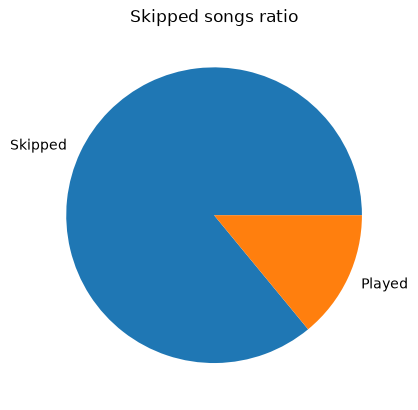

In [360]:
skip_counts = df["skippedSong"].value_counts()
skip_counts.index = ["Skipped", "Played"] 
skip_counts.plot.pie(title="Skipped songs ratio", legend="")

#### 3.4 Artists by percentage of songs skipped
For each artist in the dataset, calculate which percentage of their songs was skipped. Store this information in a new DataFrame called `df_skipped`. Store the percentage of skipped songs in a new column named `SkipRate`\
\
**Example**: If an artist has **100** songs in your dataset and **25** of these were skipped, the percentage of skipped songs for this artist would be $\frac{25}{100}=25\%$

In [361]:
artist_count = df.value_counts("artistName")
skipped_artist = df.loc[df["skippedSong"] == True].value_counts("artistName")

skip_rate = skipped_artist/artist_count

df_skipped = pd.DataFrame(skip_rate)
df_skipped.columns = ["SkipRate"]

df_skipped = df_skipped.sort_values("SkipRate")
df_skipped

,SkipRate
artistName,
Roc Boyz,0.111111
LACES,0.142857
Wham!,0.166667
Basstrologe,0.200000
Kainbeats,0.200000
...,...
No Vacation,1.000000
A Problem Squared,1.000000
tenkousei.,1.000000


#### 3.5 Comparing artists by skip-rate 
Find the `three` top artists with the lowest skip-rate and the `three` with the highest. Print their names, along with their skip-rate.

In [362]:
print(f"Lowest skip rate: {df_skipped.head(3)}")
print(f"\nHighest skip rate:\n{df_skipped[:-1].tail(3)}") # Removed NaN value

Lowest skip rate:             SkipRate
artistName          
Roc Boyz    0.111111
LACES       0.142857
Wham!       0.166667

Highest skip rate:
                   SkipRate
artistName                 
A Problem Squared       1.0
tenkousei.              1.0
Alexander Stewart       1.0


## Part 4: God Is a Data Scientist - The Ariana Deep-Dive

#### 4.0 Ariana-DataFrame: 
Create a new DataFrame called *df_ariana*, containing only rows with music by Ariana Grande.

In [363]:
df_ariana = df.loc[df["artistName"] == "Ariana Grande"]
df_ariana

,endTime,artistName,trackName,secPlayed,skippedSong
10881,2023-01-01 01:17:00,Ariana Grande,7 rings,0.139,True
10882,2023-01-01 01:17:00,Ariana Grande,7 rings,0.487,True
10883,2023-01-01 01:17:00,Ariana Grande,positions,0.417,True
10887,2023-01-01 01:17:00,Ariana Grande,Santa Baby,12.293,True
10888,2023-01-01 01:17:00,Ariana Grande,Right There (feat. Big Sean),22.929,True
...,...,...,...,...,...
11948,2023-12-07 17:46:00,Ariana Grande,Almost Is Never Enough,28.483,True
11955,2023-12-07 20:51:00,Ariana Grande,needy,26.220,True
11961,2023-12-07 21:13:00,Ariana Grande,pete davidson,0.603,True
11968,2023-12-07 21:13:00,Ariana Grande,off the table (with The Weeknd),13.448,True


#### 4.1 Average skip rate
Create a histogram of the distribution of the skip-rate values of the different artists in your DataFrame  `df_skipped`, with skip rates on one axis and number of artists on the other. \
\
Then, retrieve the skip rate for Ariana Grande from your DataFrame `df_skipped`. Run the code in the cell below. Where on this distribution does Ariana Grande fall? Do I skip her songs more than average, or less?

Average skip rate: 0.7315
Ariane Grande skip rate: 0.9953
The Ariane Grande skip rate is higher than average, and falls in the bin 0.9-1.0



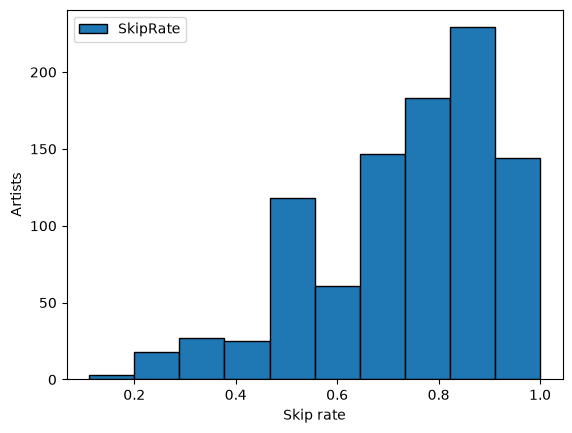

In [364]:
df_skipped.plot.hist(edgecolor="black", ylabel="Artists", xlabel="Skip rate")


print(f"""Average skip rate: {df_skipped.mean().iloc[0]:.4f}
Ariane Grande skip rate: {df_skipped.loc["Ariana Grande"].iloc[0]:.4f}
The Ariane Grande skip rate is higher than average, and falls in the bin 0.9-1.0
""")

### Part 4: Questions
Q1: Did I skip a lot of Ariana Grande's songs, or did I not, compared to the rest of the dataset? 

    You skipped a lot of Ariana Grande's songs compared to the rest of the dataset percentage wise.

Q2: What might be some possible reasons for Ariana Grande to be my nr.1 artist?
    
    Your total seconds played of her music is the highest, by quite some time